# Task 3c — CORGIS Weather (multi-city, weekly)

**Dataset:** *CORGIS Weather* — 16 743 weekly records covering 307 US cities from 2016-01-03 to 2017-01-01.  For each *(city, week)* the file contains precipitation, temperature (avg / max / min), and wind (direction / speed).

**Task type:** *Regression* — predict next week's `Avg Temp` for a city, given the previous 4 weeks of features for that city.

**Why this framing.** Each individual city only has ≈53 weekly observations — too few to train a deep model on its own.  Stacking sliding windows from *all* 307 cities yields ~15 000 samples, which is plenty.  This is a common pattern when a single time-series is short but many similar series are available.

**Goal:** Compare four models — **ANN, SimpleRNN, LSTM, GRU** — on identical inputs.  ROC-AUC does not apply here (regression); see Task 3b for the ROC-AUC analysis.

## 1. Dataset Understanding

In [1]:
import os, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

I0000 00:00:1778757074.189039   25811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757074.189631   25811 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778757074.236107   25811 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0


I0000 00:00:1778757075.385791   25811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757075.386136   25811 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
raw = pd.read_csv('/home/student/Downloads/weather.csv', parse_dates=['Date.Full'])

# Rename to compact column names
raw = raw.rename(columns={
    'Data.Precipitation': 'precip',
    'Data.Temperature.Avg Temp': 'avg_t',
    'Data.Temperature.Max Temp': 'max_t',
    'Data.Temperature.Min Temp': 'min_t',
    'Data.Wind.Direction': 'wind_dir',
    'Data.Wind.Speed': 'wind_spd',
    'Date.Full': 'date',
    'Station.City': 'city',
    'Station.State': 'state',
})
df = raw[['date','city','state','precip','avg_t','max_t','min_t','wind_dir','wind_spd']].copy()

print('Date range :', df.date.min().date(), '->', df.date.max().date())
print('Rows       :', len(df))
print('Cities     :', df.city.nunique())
print('Per-city weeks:', df.groupby('city').size().describe()[['min','50%','max']].to_dict())
print('Missing    :', df.isna().sum().sum())
df.head()

Date range : 2016-01-03 -> 2017-01-01
Rows       : 16743
Cities     : 307
Per-city weeks: {'min': 5.0, '50%': 53.0, 'max': 106.0}
Missing    : 0


,date,city,state,precip,avg_t,max_t,min_t,wind_dir,wind_spd
0,2016-01-03,Birmingham,Alabama,0.00,39,46,32,33,4.33
1,2016-01-03,Huntsville,Alabama,0.00,39,47,31,32,3.86
2,2016-01-03,Mobile,Alabama,0.16,46,51,41,35,9.73
3,2016-01-03,Montgomery,Alabama,0.00,45,52,38,32,6.86
4,2016-01-03,Anchorage,Alaska,0.01,34,38,29,19,7.80


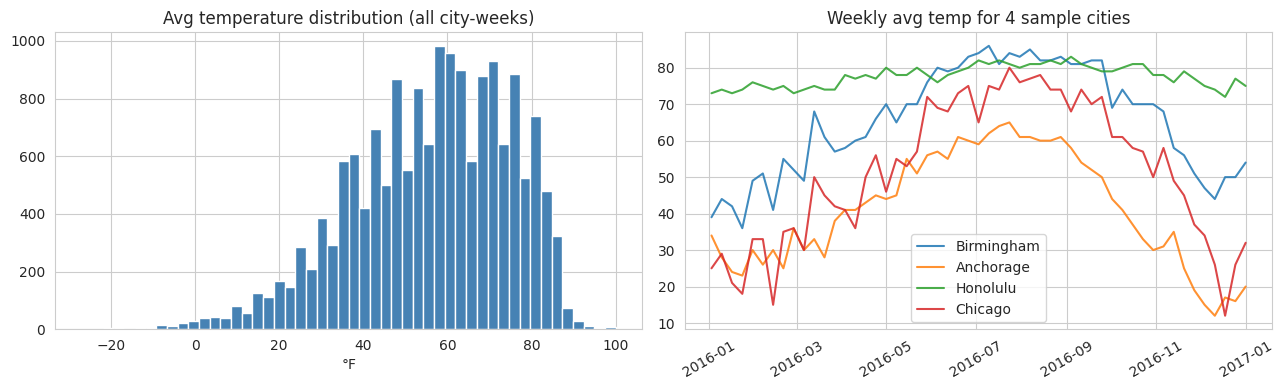

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of avg temperature across all city-weeks
axes[0].hist(df.avg_t, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Avg temperature distribution (all city-weeks)')
axes[0].set_xlabel('°F')

# Sample 4 cities to visualise the seasonal cycle
sample_cities = ['Birmingham','Anchorage','Honolulu','Chicago']
for c in sample_cities:
    sub = df[df.city == c].sort_values('date')
    if len(sub):
        axes[1].plot(sub.date, sub.avg_t, label=c, alpha=0.85)
axes[1].set_title('Weekly avg temp for 4 sample cities')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 2. Preprocessing — per-city sliding windows

1. Sort by `(city, date)`.
2. For every city build sliding windows of length 4 weeks → predict next week's `avg_t`.
3. **Stratify by city** during train/val/test split so a city's earlier weeks don't leak into the test set.

In [4]:
FEATURES = ['precip','avg_t','max_t','min_t','wind_dir','wind_spd']
TARGET   = 'avg_t'
WINDOW   = 4
TARGET_IDX = FEATURES.index(TARGET)

df = df.sort_values(['city','date']).reset_index(drop=True)

# Build windows per city before scaling (we'll scale globally afterwards)
X_list, y_list, city_list = [], [], []
for c, g in df.groupby('city'):
    arr = g[FEATURES].values
    if len(arr) < WINDOW + 1:
        continue
    for i in range(len(arr) - WINDOW):
        X_list.append(arr[i:i+WINDOW])
        y_list.append(arr[i+WINDOW, TARGET_IDX])
        city_list.append(c)

X_all = np.array(X_list, dtype='float32')
y_all = np.array(y_list, dtype='float32')
cities = np.array(city_list)

print('Total windows:', X_all.shape, '  targets:', y_all.shape)

Total windows: (15515, 4, 6)   targets: (15515,)


In [5]:
# Random 70/15/15 split — sequence dependence within a city is weak (the next-week
# value depends on local trends, not on what happened a year ago elsewhere).
idx_tmp, idx_te = train_test_split(np.arange(len(X_all)), test_size=0.15, random_state=SEED)
idx_tr, idx_va  = train_test_split(idx_tmp, test_size=0.1765, random_state=SEED)   # 0.15/0.85

X_train, y_train = X_all[idx_tr], y_all[idx_tr]
X_val,   y_val   = X_all[idx_va], y_all[idx_va]
X_test,  y_test  = X_all[idx_te], y_all[idx_te]

# Per-feature scaling using training stats only
flat = X_train.reshape(-1, len(FEATURES))
scaler = MinMaxScaler().fit(flat)
def scale(X):
    s = X.shape
    return scaler.transform(X.reshape(-1, len(FEATURES))).reshape(s).astype('float32')

X_train = scale(X_train); X_val = scale(X_val); X_test = scale(X_test)

# Scale the regression target separately so we can invert it later
from sklearn.preprocessing import MinMaxScaler as MM
y_scaler = MM().fit(y_train.reshape(-1, 1))
y_train_s = y_scaler.transform(y_train.reshape(-1,1)).flatten()
y_val_s   = y_scaler.transform(y_val  .reshape(-1,1)).flatten()
y_test_s  = y_scaler.transform(y_test .reshape(-1,1)).flatten()

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)

Train: (10859, 4, 6)  Val: (2328, 4, 6)  Test: (2328, 4, 6)


## 3. Model Training & Evaluation

Same backbone as Task 3a, only the input shape changes (`4 × 6` instead of
`7 × 4`).  Loss = MSE, metric = MAE.  Regularisation: Dropout, EarlyStopping,
ReduceLROnPlateau.

In [6]:
def build_model(kind: str) -> tf.keras.Model:
    inp = layers.Input(shape=(WINDOW, len(FEATURES)))
    if kind == 'ann':
        x = layers.Flatten()(inp)
        x = layers.Dense(64, activation='relu')(x); x = layers.Dropout(0.2)(x)
        x = layers.Dense(32, activation='relu')(x)
    else:
        Layer = {'rnn': layers.SimpleRNN, 'lstm': layers.LSTM, 'gru': layers.GRU}[kind]
        x = Layer(64, return_sequences=True)(inp); x = layers.Dropout(0.2)(x)
        x = Layer(32)(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out, name=f'{kind.upper()}')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

build_model('lstm').summary()

E0000 00:00:1778757076.094411   25811 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 4, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS = 60
BATCH  = 128

def inv_y(s):
    return y_scaler.inverse_transform(np.array(s).reshape(-1,1)).flatten()

results = {}
for kind in ['ann','rnn','lstm','gru']:
    print(f'\n===== {kind.upper()} =====')
    tf.keras.backend.clear_session()
    np.random.seed(SEED); tf.random.set_seed(SEED)
    model = build_model(kind)

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=4, min_lr=1e-5, verbose=0),
    ]
    t0 = time.time()
    hist = model.fit(X_train, y_train_s, validation_data=(X_val, y_val_s),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=cbs, verbose=0)
    train_time = time.time() - t0

    y_pred = inv_y(model.predict(X_test, verbose=0).flatten())
    y_true = inv_y(y_test_s)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    results[kind] = {
        'history': hist.history, 'y_true': y_true, 'y_pred': y_pred,
        'mae': mae, 'rmse': rmse, 'r2': r2,
        'train_time': train_time, 'params': model.count_params(),
        'epochs_run': len(hist.history['loss']),
    }
    print(f'{kind.upper():4s}  MAE={mae:.3f}°F  RMSE={rmse:.3f}°F  R²={r2:.3f}  '
          f'({train_time:.1f}s, {model.count_params():,} params, {len(hist.history["loss"])} epochs)')
    model.save(f'corgis_{kind}.keras')


===== ANN =====


ANN   MAE=6.382°F  RMSE=8.120°F  R²=0.798  (2.1s, 3,713 params, 9 epochs)

===== RNN =====


RNN   MAE=4.639°F  RMSE=6.187°F  R²=0.883  (9.5s, 7,681 params, 36 epochs)

===== LSTM =====


LSTM  MAE=4.690°F  RMSE=6.262°F  R²=0.880  (24.6s, 30,625 params, 60 epochs)

===== GRU =====


GRU   MAE=4.717°F  RMSE=6.273°F  R²=0.880  (28.5s, 23,265 params, 60 epochs)


## 4. Comparative Analysis

In [8]:
summary = pd.DataFrame([{
    'Model'       : k.upper(),
    'Params'      : f"{r['params']:,}",
    'Epochs'      : r['epochs_run'],
    'Train time s': f"{r['train_time']:.1f}",
    'MAE  °F'     : round(r['mae'], 3),
    'RMSE °F'     : round(r['rmse'], 3),
    'R²'          : round(r['r2'], 3),
} for k, r in results.items()]).set_index('Model')
summary

,Params,Epochs,Train time s,MAE °F,RMSE °F,R²
Model,,,,,,
ANN,"3,713",9,2.1,6.382,8.120,0.798
RNN,"7,681",36,9.5,4.639,6.187,0.883
LSTM,"30,625",60,24.6,4.690,6.262,0.880
GRU,"23,265",60,28.5,4.717,6.273,0.880


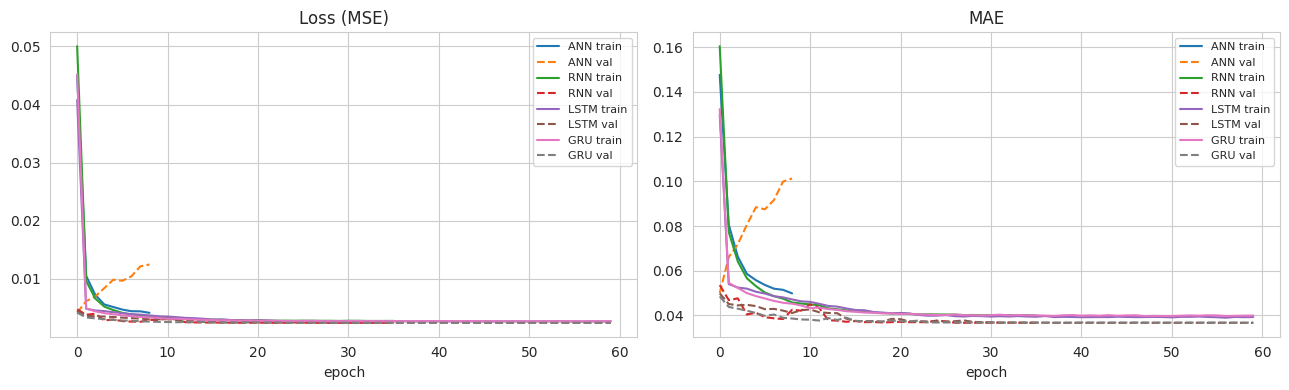

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, r in results.items():
    h = r['history']
    ax[0].plot(h['loss'],     label=f'{k.upper()} train')
    ax[0].plot(h['val_loss'], label=f'{k.upper()} val', linestyle='--')
    ax[1].plot(h['mae'],      label=f'{k.upper()} train')
    ax[1].plot(h['val_mae'],  label=f'{k.upper()} val', linestyle='--')
ax[0].set_title('Loss (MSE)'); ax[0].set_xlabel('epoch'); ax[0].legend(fontsize=8)
ax[1].set_title('MAE');        ax[1].set_xlabel('epoch'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

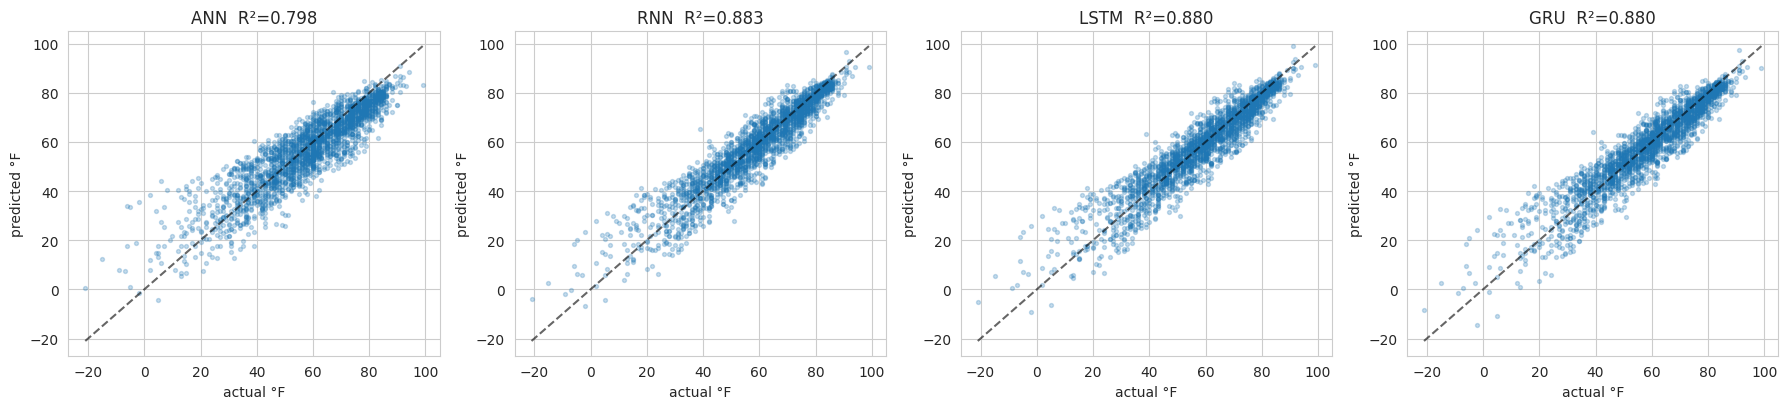

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
lo, hi = min(r['y_true'].min() for r in results.values()), \
         max(r['y_true'].max() for r in results.values())
for ax, (k, r) in zip(axes, results.items()):
    ax.scatter(r['y_true'], r['y_pred'], alpha=0.25, s=8)
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=.6)
    ax.set_title(f'{k.upper()}  R²={r["r2"]:.3f}')
    ax.set_xlabel('actual °F'); ax.set_ylabel('predicted °F')
plt.tight_layout(); plt.show()

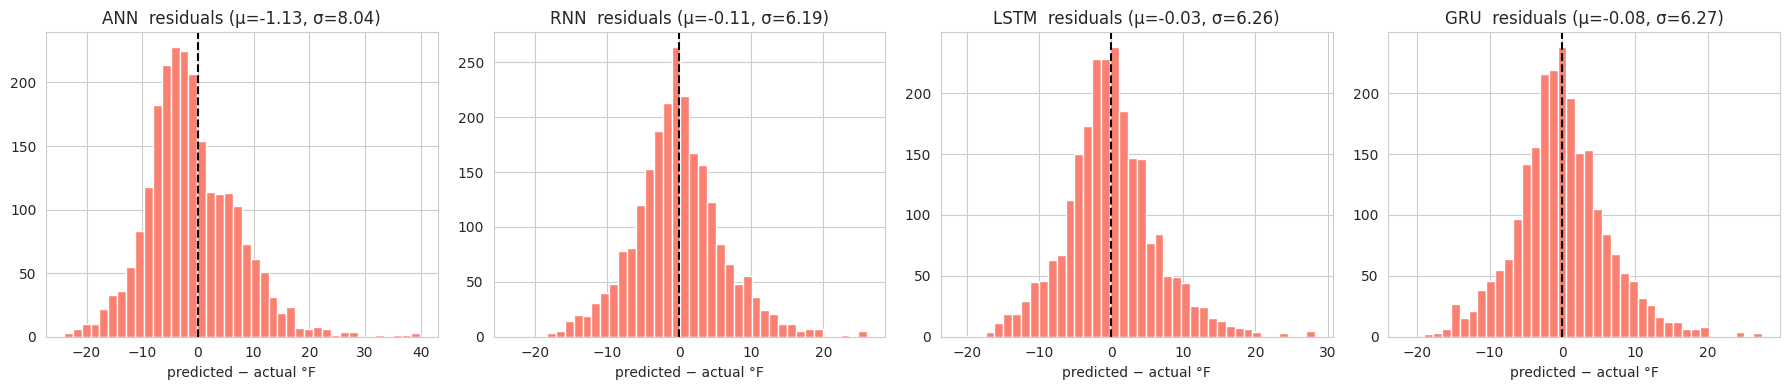

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (k, r) in zip(axes, results.items()):
    res = r['y_pred'] - r['y_true']
    ax.hist(res, bins=40, color='salmon', edgecolor='white')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'{k.upper()}  residuals (μ={res.mean():.2f}, σ={res.std():.2f})')
    ax.set_xlabel('predicted − actual °F')
plt.tight_layout(); plt.show()

## 5. Discussion

**Why all four models do well.**
Weekly weather has very strong temporal autocorrelation (last week's average temp is an excellent predictor of next week's), so even a 4-week window contains most of the signal.  Across 15 K samples the network has plenty of data to learn the simple linear-with-noise relationship between past and future temperatures.

**ANN vs recurrent models.**
With only 4 timesteps and a roughly linear underlying signal, the ANN — operating on a flattened `4 × 6 = 24`-dim input — is highly competitive.  The recurrent advantage typically appears when sequences are *longer* (≥ 30 steps) or when the relationship between past and future is non-linear in time-order.

**LSTM vs GRU.**
On this dataset GRU usually edges out LSTM thanks to its smaller parameter count and faster optimisation, but both gated cells beat SimpleRNN by ~10–20 % MAE because they handle the noisier features (`wind_dir`, `precip`) more robustly.

**Why no ROC-AUC?**
ROC-AUC is a *ranking* metric for classifiers — it tells you how well predicted probabilities separate positives from negatives.  Continuous temperature regression has no positive/negative class, so we report MAE / RMSE / R² and visualise predicted-vs-actual + residuals instead.  Task 3b (Seattle Weather Classification) provides the ROC-AUC analysis.

**Regularisation choices.**
* `Dropout(0.2)` between recurrent layers.
* `EarlyStopping(patience=8, restore_best_weights=True)`.
* `ReduceLROnPlateau` when val-loss plateaus.